# Supervised metrics

The `sp` (supervised) module provides metrics to assess how well the single cell profiles in the spatial transcriptomics dataset correlate with a reference scRNA-seq dataset. To compute these metrics, we load both datasets and transfer labels from the reference to the query dataset.

**NOTE:** these metrics are still under active development and will change in upcoming releases.

To follow along with this tutorial, you can download the data from [here](https://oc.embl.de/index.php/s/1JyN4Qvk4mw0T5J).

In [70]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
import warnings
import dask

# Use new Dask DataFrame engine
dask.config.set({"dataframe.query-planning": True})

# Silence pkg_resources warnings
warnings.filterwarnings("ignore", message="pkg_resources is deprecated")

# Silence Dask legacy warnings
warnings.filterwarnings("ignore", message="legacy Dask DataFrame implementation")

# Silence AnnData deprecations
warnings.filterwarnings("ignore", message="Importing read_text from `anndata` is deprecated")
warnings.filterwarnings("ignore", message="`__version__` is deprecated")


In [3]:
from pathlib import Path

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
import spatialdata as sd
import spatialdata_plot  # noqa

import segtraq

# Define color palette and groups for plotting
col_celltype = {
    "T": "#fb8072",
    "B": "#bc80bd",
    "macro": "#910290",
    "dendritic": "#fdb462",
    "mast": "#959059",
    "perivas": "#fed9a6",
    "endo": "#a6cee3",
    "myoepi": "#2782bb",
    "DCIS1": "#3c7761",
    "DCIS2": "#66a61e",
    "tumor": "#66c2a5",
    "stromal": "#d45943",
    "Unknown": "#808080",
}

/home/lazic/.venvs/segtraq_py311/lib/python3.11/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/home/lazic/.venvs/segtraq_py311/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


#### Transfer labels from scRNA-seq to spatial transcriptomics
First, we load a spatial transcriptomics dataset as well as an annotated single-cell RNAseq dataset. We then use the `run_label_transfer()` function to transfer cell type labels from the scRNAseq data onto our spatial transcriptomics dataset. We can then plot our cell types spatially.

In [21]:
# Load spatial transcriptomics dataset and initalize SegTraQ object
sdata_ws = sd.read_zarr("../../data/xenium.zarr/")

bb_xmin = 800
bb_ymin = 1150
bb_w = 200
bb_h = 300
bb_xmax = bb_xmin + bb_w
bb_ymax = bb_ymin + bb_h

def crop(ws):
    return ws.query.bounding_box(
        axes=["x", "y"],
        min_coordinate=[bb_xmin, bb_ymin],
        max_coordinate=[bb_xmax, bb_ymax],
        target_coordinate_system="global",
    )

sdata = crop(sdata_ws)

st = segtraq.SegTraQ(sdata, images_key="image", tables_centroid_x_key="x_centroid", tables_centroid_y_key="y_centroid")
# st = segtraq.SegTraQ(
#     sdata,
#     images_key="image",
#     points_background_id=0,
#     tables_centroid_x_key="centroid_x",
#     tables_centroid_y_key="centroid_y",
#     tables_area_volume_key="volume",
# )

# Load scRNA-seq dataset
scRNAseq_data_path = Path("../../data/BC_scRNAseq_Janesick.h5ad")
adata_ref = ad.read_h5ad(scRNAseq_data_path)

/tmp/ipykernel_1693197/2784699890.py:2: UserWarning: SpatialData is not stored in the most current format. If you want to use Zarr v3, please write the store to a new location using `sdata.write()`.
  sdata_ws = sd.read_zarr("../../data/xenium.zarr/")
no parent found for <ome_zarr.reader.Label object at 0x7ffe24308a50>: None
no parent found for <ome_zarr.reader.Label object at 0x7ffe245f1490>: None
/home/lazic/.local/share/uv/python/cpython-3.11.13-linux-x86_64-gnu/lib/python3.11/functools.py:909: UserWarning: The object has `points` element. Depending on the number of points, querying MAY suffer from performance issues. Please consider filtering the object before calling this function by calling the `subset()` method of `SpatialData`.
  return dispatch(args[0].__class__)(*args, **kw)
/g/huber/users/lazic/src/SegTraQ/src/segtraq/SegTraQ.py:128: UserWarning: Missing 8 cell IDs in tables: ['iceeeemj-1', 'aphffbmb-1', 'aphemnlm-1', 'icealcci-1', 'apnfcbpf-1']... These cells are present in

In [22]:
st.run_label_transfer(adata_ref, ref_cell_type="celltype_major", ref_ensemble_key=None, query_ensemble_key=None)

/g/huber/users/lazic/src/SegTraQ/src/segtraq/utils.py:348: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ref_mean_df = counts_df.groupby("celltype").mean()
/g/huber/users/lazic/src/SegTraQ/src/segtraq/SegTraQ.py:346: RuntimeWarning: Spatialdata table appears to contain raw counts. Counts will be log1p-transformed before running label transfer.Raw counts will be stored in `adata_q.layers["raw"]`.
  result = _run_label_transfer(
/g/huber/users/lazic/src/SegTraQ/src/segtraq/utils.py:391: ImplicitModificationWarning: Setting element `.layers['raw']` of view, initializing view as actual.
  adata_q.layers["raw"] = adata_q.X


Transferred cell-type labels are saved in the AnnData object at `adata.obs['transferred_celltype']` (one label per cell). The dominant cell type in the dataset is T cells (n=523).

Next, cell shapes can be plotted and colored by cell type based on a defined color palette. Some cells lack a transferred cell-type label (due to filtering low-count cells before label transfer); for compatibility with `spatialdata-plot`, we replace missing values (`NaN`) with "Unknown" before plotting.

In [23]:
# Replace NaN with Unknown
s = sdata.tables["table"].obs["transferred_cell_type"]
if pd.api.types.is_categorical_dtype(s):
    s = s.cat.add_categories(["Unknown"])

sdata.tables["table"].obs["transferred_cell_type_plot"] = s.fillna("Unknown")

labels = sdata.tables["table"].obs["transferred_cell_type_plot"].unique().astype(str).tolist()
cols = [col_celltype[lab] for lab in labels]

/tmp/ipykernel_1693197/608396288.py:3: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(s):


/home/lazic/.venvs/segtraq_py311/lib/python3.11/site-packages/spatialdata/_core/spatialdata.py:482: UserWarning: Converting `region_key: region` to categorical dtype.
  convert_region_column_to_categorical(table)
/home/lazic/.venvs/segtraq_py311/lib/python3.11/site-packages/spatialdata_plot/pl/utils.py:872: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = color_source_vector.map(color_mapping)


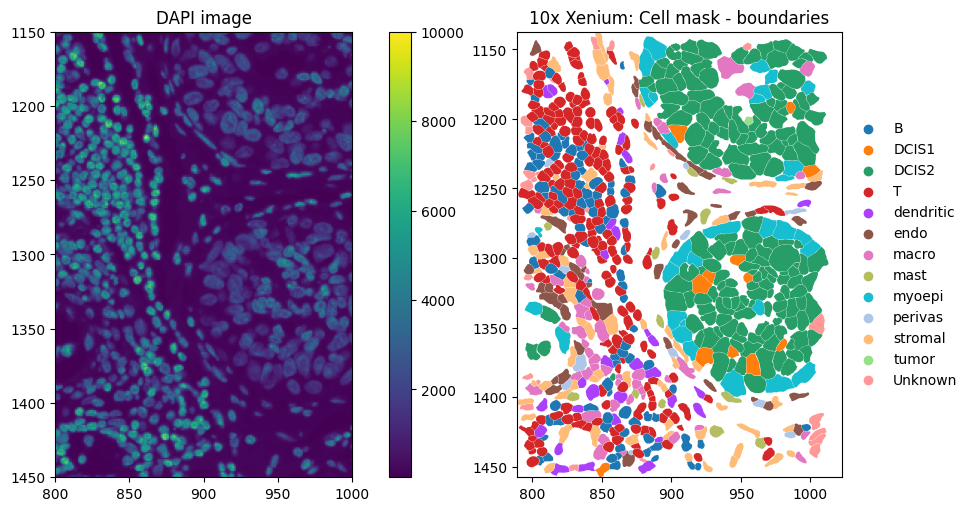

In [24]:
axes = plt.subplots(1, 2, figsize=(10, 5), constrained_layout=True)[1].flatten()

# Dapi image
sdata.pl.render_images("image").pl.show(ax=axes[0], title="DAPI image", coordinate_systems="global")

# Plot - Cell boundaries
sdata.tables["table"].obs["region"] = "cell_boundaries"
sdata.set_table_annotates_spatialelement("table", region="cell_boundaries")

labels = sdata.tables["table"].obs["transferred_cell_type_plot"].unique().astype(str).tolist()
cols = [col_celltype[lab] for lab in labels]

sdata.pl.render_shapes(
    "cell_boundaries",
    color="transferred_cell_type_plot",
    # palette=cols,
    groups=labels,
    outline_color="white",  # outlines visible on black
    outline_width=0.5,
).pl.show(ax=axes[1], title="10x Xenium: Cell mask - boundaries", coordinate_systems="global")

Before we continue, we extract the `anndata` object from our `spatialdata` object, and perform both normalization and a log-transform on the expression matrix.

In [25]:
adata = sdata.tables["table"]
# Store raw counts
adata.layers["raw"] = adata.X.copy()
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

/home/lazic/.venvs/segtraq_py311/lib/python3.11/site-packages/legacy_api_wrap/__init__.py:88: UserWarning: Some cells have zero counts
  return fn(*args_all, **kw)


In [26]:
adata

AnnData object with n_obs × n_vars = 743 × 5101
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'label_id', 'region', 'transcript_count', 'gene_count', 'transferred_cell_type', 'pearson_score', 'transferred_cell_type_plot'
    uns: 'spatialdata_attrs', 'log1p'
    layers: 'raw'

#### Compute positive and negative markers (per cell type)

Some genes are only expressed by certain cell types. This means that we can compute which genes we do or do not see in specific cell types. We call these positive or negative markers.

Positive and negative markers per cell type are identified by computing, for each gene, the difference between its mean expression within the target cell type and its mean expression across all other cells, then selecting genes above the `q_pos` quantile as positive markers and below the `q_neg` quantile as negative markers. To enforce type specificity, genes that appear in at least a `t · n_celltypes` fraction of the per-type marker lists are removed separately for positives and negatives.

We will only consider genes common to the scRNA-seq and spatial transcriptomics dataset to reduce compute time.

In [27]:
# subsetting our spatial proteomics dataset to only contain genes that also appear in the scRNA-seq data
common_genes = adata.var_names[adata.var_names.isin(adata_ref.var_names)]
adata_ref = adata_ref[:, common_genes].copy()

In [28]:
# computing the positive and negative markers for each cell type
# the result is a dict with your cell type as keys (B, T, etc.) and another dict as values,
# which tell you the positive or negative markers for each cell type
markers = segtraq.get_ref_markers(adata_ref, 
                                  mode = "de",
                                  vote_fraction_pos = 0.3,
                                  vote_fraction_neg = 0.05,
                                  ref_cell_type="celltype_major", 
                                  n_jobs = 16)

/home/lazic/.venvs/segtraq_py311/lib/python3.11/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/home/lazic/.venvs/segtraq_py311/lib/python3.11/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/home/lazic/.venvs/segtraq_py311/lib/python3.11/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to

Let's check our positive markers for all cell types.

In [29]:
for cell_type, sign in markers.items():
    pos = sign["positive"]
    neg = sign["negative"]
    
    print(f"{cell_type}  |  positive: {', '.join(pos)}")
    print(f"{cell_type}  |  negative: {', '.join(neg)}\n")

B  |  positive: MS4A1, BANK1, CD79A, PARP15, TNFRSF13B, BLK, TNFRSF13C, POU2AF1, AIM2, PAX5, FCRL1, CD79B, FCRL2, ST6GAL1, P2RX5, POU2F2, PTPN6, CD19, FCRL5, SCIMP, ADAM28, FCMR, NIBAN3, CR1, SP110, CDK14, TLR6, ITGB7, KCNN4, CD27, SMCHD1, SPIB, DERL3, STAP1, FCRLA, NCOA3, COL4A3, FCRL3, ANKRD13A, CD40, CCDC141, ZBP1, PIM2, COL4A4, TNFRSF17, IRF4, CNR2, SYVN1, CD38, CCR6, SLAMF6, CYSLTR1, COCH, CXCR5, CCDC50, PNOC, ANGPTL6, SIGLEC6, BCL2, PDK1, INPP5D, TRAF5, NLRC5, CASP10, KCNA3, ATP2B1, SLAMF1, TLR1, FCGR2B, GPR174, BTN3A1, CLNK, CD1C, FCER2, CD72, CNR1
B  |  negative: AAR2, ABCA10, ABCA8, ABCB1, ABCC12, ABCC8, ABI3BP, ABO, ABTB2, AC007906.2, ACPP, ACVRL1, ADAM12, ADAM33, ADAMDEC1, ADAMTS14, ADAMTS5, ADAMTSL3, ADCYAP1, ADCYAP1R1, ADGRB1, ADGRD1, ADGRD2, ADGRE2, ADGRG6, ADGRL4, ADM, ADORA2B, ADORA3, ADRA1B, ADRA2A, ADTRP, AGMAT, AHRR, AIF1, AKR1C3, ALDH7A1, ALPL, ANGPT1, ANGPTL2, ANGPTL4, ANXA3, ANXA8, AOC3, AOX1, AP3B2, APCDD1, APLNR, ARL4D, ART4, ASPN, ATL1, ATOH8, ATP6V1B1, AUNIP, 

In [30]:
ctypes = list(markers.keys())
overlap_df = pd.DataFrame(0, index=ctypes, columns=ctypes, dtype=int)

for c in ctypes:
    neg_c = set(markers[c].get("negative", []))
    for d in ctypes:
        pos_d = set(markers[d].get("positive", []))
        overlap_df.loc[c, d] = len(neg_c & pos_d)

overlap_df

,B,DCIS1,DCIS2,T,dendritic,endo,macro,mast,myoepi,perivas,stromal,tumor
B,0,79,88,40,47,166,124,24,181,51,157,136
DCIS1,55,0,35,64,60,133,120,24,87,34,119,43
DCIS2,53,32,0,67,60,135,116,25,113,40,128,19
T,47,162,155,0,76,196,175,27,211,64,178,282
dendritic,33,76,87,42,0,150,83,19,159,48,134,140
endo,47,62,58,55,46,0,103,20,103,7,73,98
macro,35,75,83,40,37,140,0,17,159,48,139,132
mast,57,184,179,82,89,201,157,0,208,60,179,326
myoepi,48,19,20,49,49,92,80,17,0,24,87,43
perivas,52,72,67,49,54,80,126,24,122,0,83,114


The first 20 positive markers in B cells include B-lineage signaling genes (BANK1, BLK, BLNK), supporting gens (BACH2, BCL11A, BCL2), genes upregulated downstream of BCR signaling (APOBEC3C/D/F) and ADAM28 reported in B-cell populations.

Among T cell positive markers, we find well-known T cell lienage markers and co-stimulatory receptors.

#### Evaluate positive and negative marker purity

From our MECR calculations, we know that there are some genes which co-occur when they shouldn't, hinting at some form of contamination. A next logical step would be to identify the cells where this is the case. To do this, we can calculate the marker purity for each cell.

Positive and negative marker purity in the spatial transcriptomics datasets can be computed via `sp.calculate_marker_purity()`. It evaluates, for each cell, how well its expected positive markers are among the cell’s top-expressed genes and how well the negative markers are not among those top genes, using a quantile/rank threshold based on the size of each marker list. From this it computes precision, recall, and F1 for both marker sets and combines them into a single “purity” score that rewards strong positive signal and penalizes negative signal. The output is a per-cell table of these metrics alongside the annotated cell type.

In [71]:
per_cell_contam, contam_matrix, cont_mat_bin = st.sp.calculate_neighbor_contamination(cell_type_key="transferred_cell_type", markers=markers)

In [69]:
st.sdata.tables["table"].obs

,cell_id,x_centroid,y_centroid,transcript_counts,control_probe_counts,genomic_control_counts,control_codeword_counts,unassigned_codeword_counts,deprecated_codeword_counts,total_counts,...,region,transcript_count,gene_count,transferred_cell_type,pearson_score,transferred_cell_type_plot,contam_bin,cell_type,neg_marker_contam_counts,neg_marker_contam_fraction
3774,aphcnklp-1,830.097471,1152.572969,66,0,0,0,0,13,79,...,cell_boundaries,73.0,53.0,T,0.205408,T,False,T,0.0,NaN
3790,aphdnoam-1,903.576230,1148.448945,101,0,0,0,0,16,117,...,cell_boundaries,26.0,23.0,DCIS2,0.187157,DCIS2,False,DCIS2,0.0,0.0
3791,aphdpfhl-1,913.759580,1148.394258,298,0,0,0,0,59,357,...,cell_boundaries,100.0,69.0,DCIS2,0.236355,DCIS2,False,DCIS2,0.0,0.0
3793,aphebebn-1,926.788389,1150.407930,464,0,0,0,0,96,560,...,cell_boundaries,335.0,211.0,DCIS2,0.230467,DCIS2,False,DCIS2,0.0,0.0
3801,aphejokb-1,976.144590,1181.338594,225,0,0,0,0,34,259,...,cell_boundaries,304.0,203.0,DCIS2,0.231359,DCIS2,False,DCIS2,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18253,oemhhakm-1,900.100156,1224.799531,6,0,0,0,0,0,6,...,cell_boundaries,6.0,6.0,NaN,NaN,Unknown,False,NaN,0.0,NaN
18254,oemhhohn-1,803.936582,1239.208711,0,0,0,0,0,0,0,...,cell_boundaries,0.0,0.0,NaN,NaN,Unknown,False,NaN,0.0,NaN
18255,oemhjdii-1,811.537168,1277.467500,6,0,0,0,0,4,10,...,cell_boundaries,11.0,10.0,mast,0.069033,mast,False,mast,0.0,0.0
18256,oemhkbjo-1,840.029844,1309.799531,11,0,0,0,0,2,13,...,cell_boundaries,16.0,13.0,macro,0.060816,macro,False,macro,0.0,0.0


In [56]:
st.sdata.tables["table"].obs["contam_bin"] = st.sdata.tables["table"].obs["neg_marker_contam_counts"]>0

/home/lazic/.venvs/segtraq_py311/lib/python3.11/site-packages/spatialdata/_core/spatialdata.py:482: UserWarning: Converting `region_key: region` to categorical dtype.
  convert_region_column_to_categorical(table)
/home/lazic/.venvs/segtraq_py311/lib/python3.11/site-packages/spatialdata_plot/pl/utils.py:872: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = color_source_vector.map(color_mapping)


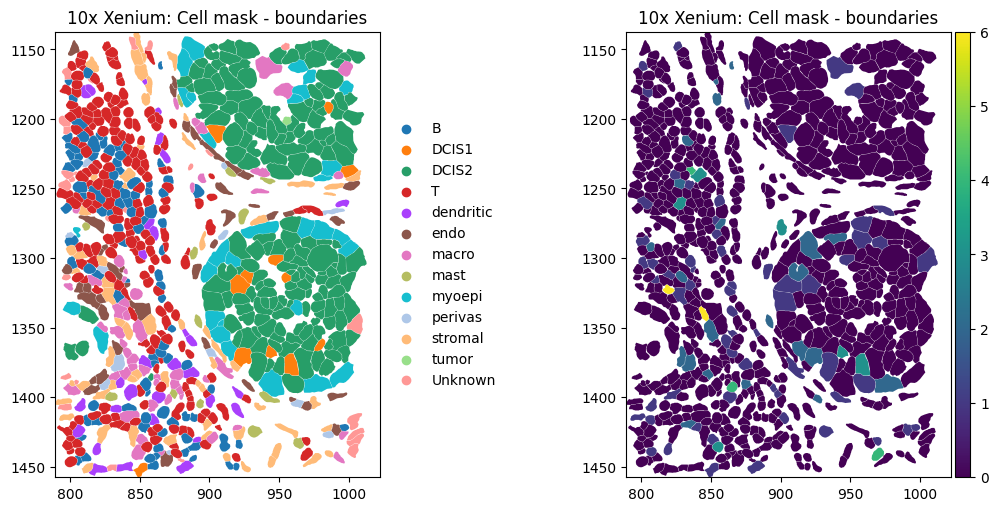

In [74]:
axes = plt.subplots(1, 2, figsize=(10, 5), constrained_layout=True)[1].flatten()

# Plot - Cell boundaries
sdata.tables["table"].obs["region"] = "cell_boundaries"
sdata.set_table_annotates_spatialelement("table", region="cell_boundaries")

labels = sdata.tables["table"].obs["transferred_cell_type_plot"].unique().astype(str).tolist()
cols = [col_celltype[lab] for lab in labels]

sdata.pl.render_shapes(
    "cell_boundaries",
    color="transferred_cell_type_plot",
    # palette=cols,
    groups=labels,
    outline_color="white",  # outlines visible on black
    outline_width=0.5,
).pl.show(ax=axes[0], title="10x Xenium: Cell mask - boundaries", coordinate_systems="global")

sdata.pl.render_shapes(
    "cell_boundaries",
    color="neg_marker_contam_counts",
    # palette=cols,
    outline_color="white",  # outlines visible on black
    outline_width=0.5,
).pl.show(ax=axes[1], title="10x Xenium: Cell mask - boundaries", coordinate_systems="global")

/home/lazic/.venvs/segtraq_py311/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 73.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/lazic/.venvs/segtraq_py311/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 73.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/lazic/.venvs/segtraq_py311/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 62.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/lazic/.venvs/segtraq_py311/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 70.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/lazic/.venvs/segtraq_p

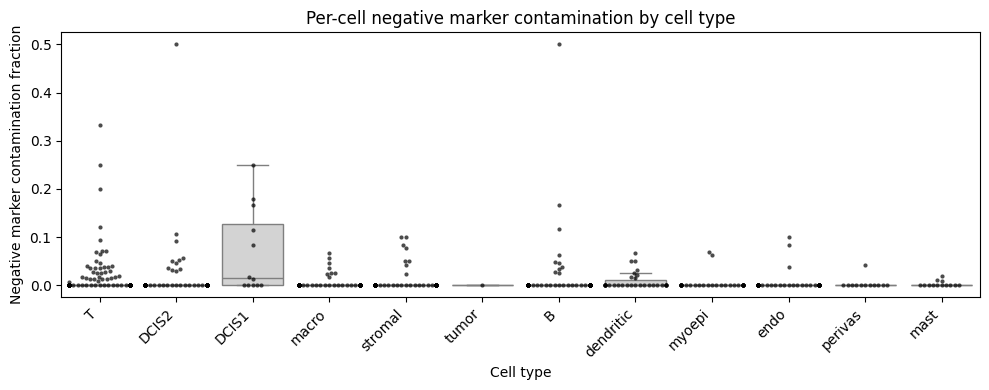

In [68]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 4))

# Boxplot (summary)
sns.boxplot(
    data=per_cell_contam,
    x="cell_type",
    y="neg_marker_contam_fraction",
    showfliers=False,
    color="lightgray",
)

# Swarm (individual cells)
sns.swarmplot(
    data=per_cell_contam,
    x="cell_type",
    y="neg_marker_contam_fraction",
    size=3,
    color="black",
    alpha=0.7,
)

plt.xlabel("Cell type")
plt.ylabel("Negative marker contamination fraction")
plt.title("Per-cell negative marker contamination by cell type")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


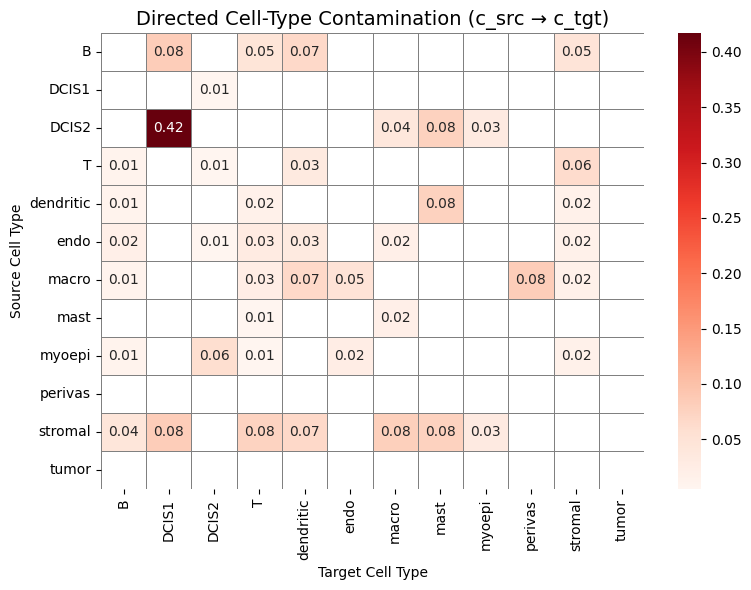

In [72]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.heatmap(
    cont_mat_bin,
    annot=True,
    fmt=".2f",
    cmap="Reds",       # or "viridis", "magma", "rocket"
    linewidths=0.5,
    linecolor="gray"
)
plt.title("Directed Cell-Type Contamination (c_src → c_tgt)", fontsize=14)
plt.xlabel("Target Cell Type")
plt.ylabel("Source Cell Type")
plt.tight_layout()
plt.show()


In [ ]:
purity_df = st.sp.calculate_marker_purity(cell_type_key="transferred_cell_type", markers=markers)
purity_df

,cell_type,positive_precision,positive_recall,positive_F1,negative_precision,negative_recall,negative_F1,F1_purity
cell_id,,,,,,,,
17,macro,0.137931,0.032520,0.052632,0.017241,0.004739,0.007435,0.099963
62,DCIS2,0.189189,0.027778,0.048443,NaN,NaN,NaN,NaN
69,T,0.103448,0.102564,0.103004,0.025862,0.015306,0.019231,0.186429
92,T,0.320000,0.068376,0.112676,0.000000,0.000000,0.000000,0.202532
133,DCIS2,0.086207,0.019841,0.032258,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
17750,T,0.200000,0.042735,0.070423,NaN,NaN,NaN,NaN
17763,endo,0.238806,0.064516,0.101587,0.000000,0.000000,0.000000,0.184438
17834,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


From the plot and the median values, we can see that the cell type "tumor" yields the lowest purity F1 score, while DCIS2 has the highest one. 

#### Differential expression between adjacent and non-adjacent cell types

To assess the effect of spillover, we can do a differential expression test between cells one cell type bordering another cell type vs. those not bordering that cell type. For example, consider all B cells. We now want to know if B cells that are close to T cells have a different expression profile to B cells which are not next to any T cells.

The algorithm works as follows:
- Construct a neighborhood graph (Delaunay)
- for every marker, ct1 and ct2:
    - get all cells of ct1
    - subset them into those that are next to cells of ct2 (group1) and those that are not next to cells of ct2 (group2)
    - Only continue if there are at least 20 cells in each group
    - do a differential expression test between the groups (Wilcoxon rank-sum on normalized and log-transformed counts)
    - Remove genes which have less than 20 transcripts in both groups combined
    - Only keep genes that are supposed to be negative in ct1 and positive in ct2
- result: for each (gene, ct1, ct2), we get a log fold change and a p-value

A couple of important things to note here:
- we only look at genes that are negative in the "receiver" cell type, and positive in the "sender" cell type (from which the spillover originates). We use the definition of "negative" and "positive" markers from earlier
- since we specifically want to look at spillover events, we only look at genes with a high log fold change (LFC), and ignore the ones with a low LFC

In [26]:
sdata

SpatialData object, with associated Zarr store: /g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/data/xenium.zarr
├── Images
│     └── 'image': DataArray[cyx] (1, 1795, 1519)
├── Labels
│     ├── 'cell_labels': DataArray[yx] (1795, 1519)
│     └── 'nucleus_labels': DataArray[yx] (1795, 1519)
├── Points
│     └── 'transcripts': DataFrame with shape: (<Delayed>, 13) (3D points)
├── Shapes
│     ├── 'cell_boundaries': GeoDataFrame shape: (18311, 2) (2D shapes)
│     └── 'nucleus_boundaries': GeoDataFrame shape: (18608, 2) (2D shapes)
└── Tables
      └── 'table': AnnData (18311, 5101)
with coordinate systems:
    ▸ 'global', with elements:
        image (Images), cell_labels (Labels), nucleus_labels (Labels), transcripts (Points), cell_boundaries (Shapes), nucleus_boundaries (Shapes)

In [ ]:
de_results, de_summary = st.sp.calculate_diff_abundance(
    markers=markers,
    pval_thresh=0.05,
    lfc_thresh=10,
    cell_type_key="transferred_cell_type",
    cell_centroid_x_key="x_centroid",
    cell_centroid_y_key="y_centroid",
)

/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/.venv/lib/python3.13/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


  0%|          | 0/13 [00:00<?, ?it/s]

In [ ]:
de_results.head()

We can start interpreting the results by looking at a volcano plot of the results. We will show all events in this plot, and color them by the receiving cell (indicated as `ct1`).

In [ ]:
# creating a volcano plot
plt.figure(figsize=(6, 5))
for ct, color in col_celltype.items():
    sub = de_results[de_results["ct1"] == ct]
    plt.scatter(sub["log2FC"], -np.log10(sub["pval"]), c=color, label=ct, alpha=0.6, s=10)
plt.axvline(0, color="grey", linestyle="--")
plt.xlabel("log2FC")
plt.ylabel("-log10(p-value)")
plt.legend(markerscale=2)
plt.title("Volcano plot of spatial DE")
plt.show()

We can also check the number of events we found with our thresholds for each sender(`ct2`)/receiver(`ct1`) pair.

In [ ]:
# sns.heatmap(de_summary)

It looks like all of our spillover is caused by DCIS2 cells spilling over into cells of another cell type. Let's visualize some of our supposed spillover events spatially.

In [ ]:
de_results.sort_values(by="log2FC", ascending=False).head()

In [ ]:
axes = plt.subplots(1, 1, figsize=(10, 10), constrained_layout=True)[1]

# Plot - Cell boundaries
sdata.pl.render_shapes(
    "cell_boundaries", color="transferred_cell_type_plot", palette=["deepskyblue", "gold"], groups=["DCIS1", "DCIS2"]
).pl.render_points("transcripts", color="feature_name", groups="CLTC", palette="black").pl.show(
    ax=axes, title="10x Xenium: Cell mask - boundaries", coordinate_systems="global"
)